In [1]:
# Design of a 120 ns selective pulse that maps |0> to a DIFFERENT computational
# outcome depending on the qubit's detuning: |0> -> |0> when detuned by -2.5 MHz,
# and |0> -> |1> when detuned by +2.5 MHz.
# The qubits are modeled as ideal two-level systems (n_levels = 2).
# Selectivity is achieved by simultaneously optimizing over two ensemble
# members corresponding to the two detunings, each with its own StateTarget.
# The pulse amplitude is constrained such that
#                 2*pi*nu_ref*(ux^2+uy^2)^(1/2) < 8 MHz.
#
# The resulting sequence resembles a Ramsey experiment.
# Note: This solution was shown to be time-optimal (Phys. Rev. A 98, 043421)
# for the equivalent (swapped-target) problem in the original GRAPE_SCQ example.
# Estimated script runtime: ~5 minutes.

# AUTHOR:
#     Leo Van Damme / Technical University of Munich, 2025

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from grape_scq import Transmon, StateTarget, OptimizationProblem, GrapeOptimizer, initial_guess

In [3]:
# Physical system: two ensemble members, at +/- 2.5 MHz detuning
system = Transmon(
    n_levels=2,
    frequency=5e9 + np.array([-2.5e6, 2.5e6]),
    carrier_frequency=5e9,
)
# Both members start in |0>; member 0 (detuning -2.5 MHz) targets |0>, member 1 (+2.5 MHz) targets |1>
target = StateTarget(initial=[[1, 0], [1, 0]], target=[[1, 0], [0, 1]])
problem = OptimizationProblem(system, target, n_steps=120, dt=1e-9)

In [4]:
# Initial guess: constant drive
pulse0 = initial_guess.zero(problem)
pulse0.ux[:] = 1.0

In [5]:
# Optimize the pulse under an amplitude constraint
optimizer = GrapeOptimizer(max_iter=2000, max_amplitude=8e6)
result = optimizer.optimize(problem, pulse0)

Compiling cost function... Done.
GRAPE optimization result
  cost:      0.500000 -> 0.000520
  fidelity:  0.500000 -> 0.999480
  iterations: 2000
  message:   The maximum number of function evaluations is exceeded.


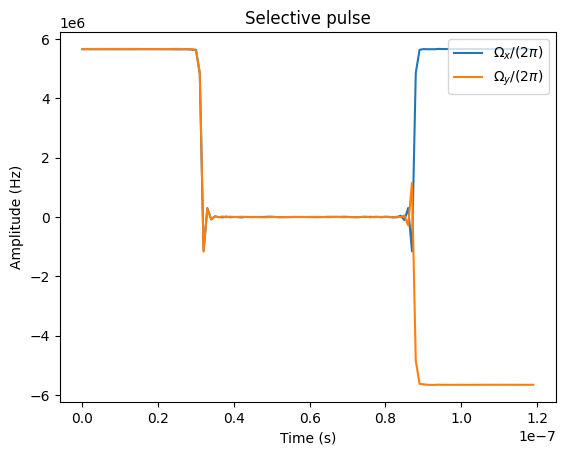

In [6]:
# Display in-phase and quadrature pulse components
result.plot_pulse(compare_to_initial=False)
plt.title("Selective pulse")
plt.show()

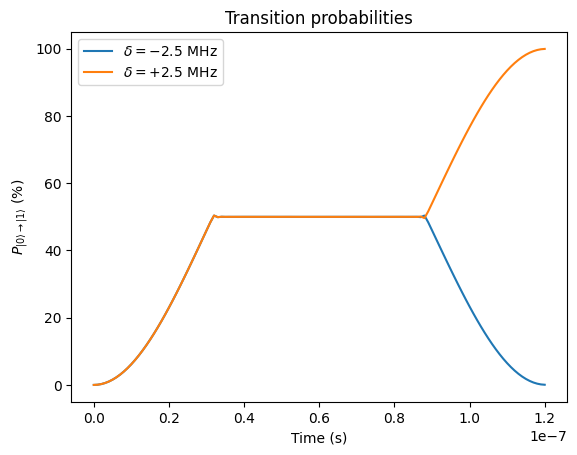

In [7]:
# Display transition probabilities |0> -> |1> for both ensemble members
plt.figure()
plt.plot(problem.t, result.population(0, 1)*100)
plt.xlabel('Time (s)')
plt.ylabel(r'$P_{|0\rangle\rightarrow|1\rangle}$ (%)')
plt.legend([r'$\delta = -2.5$ MHz', r'$\delta = +2.5$ MHz'])
plt.title("Transition probabilities")
plt.show()